   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000


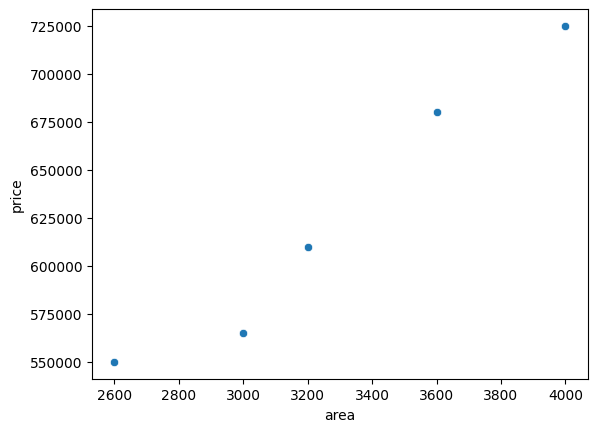

Price for 3300 sq.ft: 628715.7534246575
Slope: 135.78767123287673
Intercept: 180616.43835616432
Manual Prediction: 628715.7534246575
Price for 5000 sq.ft: 859554.7945205481
R² Score: 0.9584301138199486


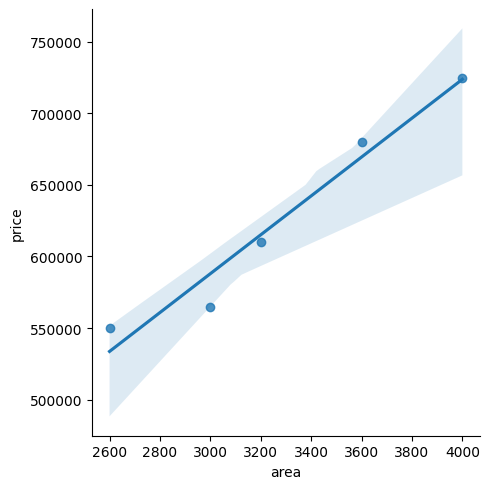

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("homeprices.csv")

print(df)

# Scatter plot
sns.scatterplot(data=df, x="area", y="price")
plt.show()

# Train model
model = LinearRegression()

X = df[["area"]]
y = df["price"]

model.fit(X, y)

# Prediction for 3300 sq.ft
prediction_3300 = model.predict(pd.DataFrame({"area":[3300]}))
print("Price for 3300 sq.ft:", prediction_3300[0])

# Slope and Intercept
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Manual Prediction
manual = model.coef_[0] * 3300 + model.intercept_
print("Manual Prediction:", manual)

# Prediction for 5000 sq.ft
prediction_5000 = model.predict(pd.DataFrame({"area":[5000]}))
print("Price for 5000 sq.ft:", prediction_5000[0])

# R² Score
predicted = model.predict(X)
print("R² Score:", r2_score(y, predicted))

# Regression Plot
sns.lmplot(data=df, x="area", y="price")
plt.show()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.head())


# Separate X and y
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================================
# LINEAR REGRESSION
# =========================================================

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


# =========================================================
# RIDGE REGRESSION
# =========================================================

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)


# =========================================================
# LASSO REGRESSION
# =========================================================

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)


# =========================================================
# ELASTIC NET
# =========================================================

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)

y_pred_elastic = elastic.predict(X_test_scaled)


# =========================================================
# COEFFICIENT TABLE
# =========================================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "Elastic Net": elastic.coef_
})

print("\n" + "=" * 80)
print("COEFFICIENTS")
print("=" * 80)

print(coefficients.to_string(index=False))


# =========================================================
# MODEL EVALUATION
# =========================================================

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)


# =========================================================
# RESULTS TABLE
# =========================================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],
    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_elastic
    ],
    "MAE": [
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_elastic
    ],
    "R2": [
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_elastic
    ]
})

print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(results.to_string(index=False))


# =========================================================
# GRAPH 1: COEFFICIENT COMPARISON
# =========================================================

coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Coefficient Comparison of Regression Models")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--")
plt.legend(title="Models")
plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 2: ACTUAL VS PREDICTED - LINEAR REGRESSION
# =========================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted - Linear Regression")

plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 3: R2 SCORE COMPARISON
# =========================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.xlabel("Regression Model")
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 4: RMSE COMPARISON
# =========================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 5: MAE COMPARISON
# =========================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.xlabel("Regression Model")
plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
<class 'pandas.core.

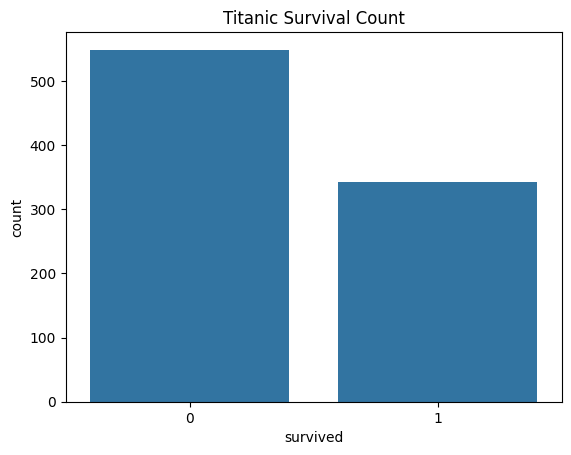

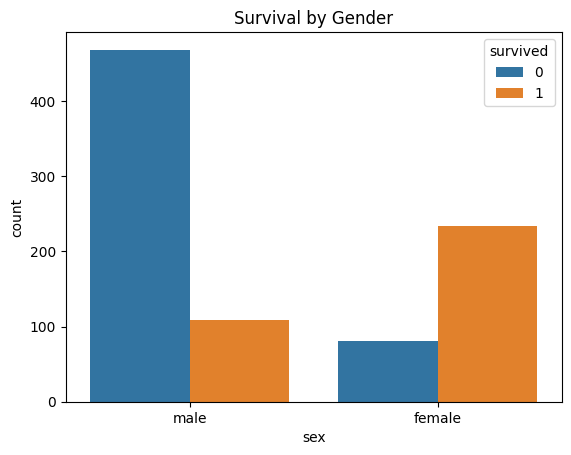

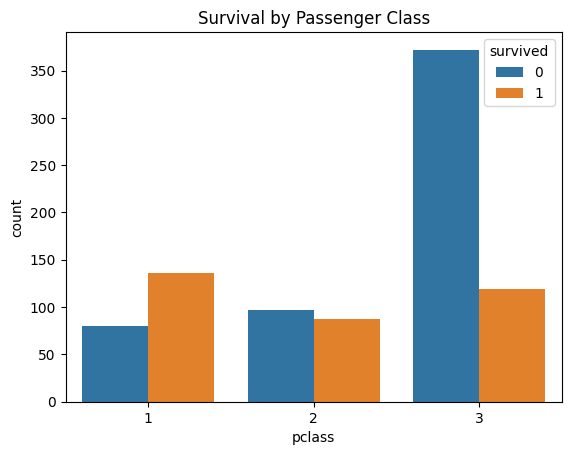

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64
   pclass   age  sibsp  parch     fare  sex_male  embarked_Q  embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True
Model training completed
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [ ]:
#Titanic Survival — Full Logistic Regression Pipeline Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#load the dataset
df = pd.read_csv("titanic.csv")
print(df.head())
print(df.shape)
print(df.columns)
#Target (y) = survived
#to understand the data set
print(df.info())
print(df.describe())
print(df.isnull().sum())#check missing values
#EDA
sns.countplot(x="survived", data=df)
plt.title("Titanic Survival Count")
plt.show()
#survival by gender
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival by Gender")
plt.show()
sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()
#select the required features
features = ["pclass","sex","age","sibsp","parch","fare","embarked"]
X = df[features].copy()
y = df["survived"]
#for numer is age use median //missing values
X["age"] = X["age"].fillna(X["age"].median())
#for categorical colum use mode
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])
print(X.isnull().sum())
X = pd.get_dummies(X,columns=["sex", "embarked"],drop_first=True)
print(X.head())
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42,stratify=y)
scaler = StandardScaler()
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model training completed")
y_pred = model.predict(X_test_scaled)
print(y_pred[:20])